In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Flatten
%matplotlib inline
import numpy as np
import warnings
warnings.filters("ignore")

In [156]:
(X_train, y_train), (X_test, y_test)=keras.datasets.mnist.load_data()

In [157]:
len(X_train)

60000

In [158]:
len(X_test)

10000

In [159]:
X_train[0].shape

(28, 28)

In [160]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

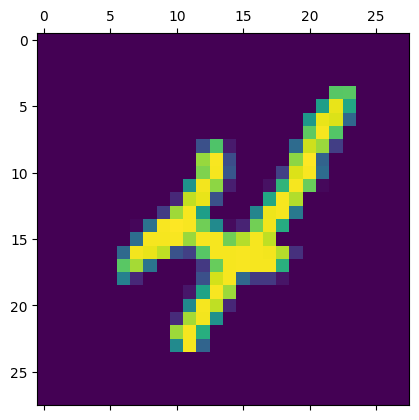

In [161]:
plt.matshow(X_train[9])

In [162]:
y_train[9]

np.uint8(4)

In [163]:
X_train = X_train/255
X_test = X_test/255

In [164]:
# converting 2d array into 1 dimension
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [165]:
X_train_flattened[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [166]:
X_train_flattened.shape

(60000, 784)

In [167]:
# now we create a simple neural network
model = keras.Sequential([
    Dense(784),
    Dense(10, activation="softmax")
])
model.compile(
    optimizer = 'adam',
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

#model actually trains here
model.fit(X_train_flattened, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8926 - loss: 0.3764
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9082 - loss: 0.3274
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9119 - loss: 0.3114
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9148 - loss: 0.3029
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9176 - loss: 0.2953


In [168]:
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9149 - loss: 0.3092


[0.30921265482902527, 0.914900004863739]

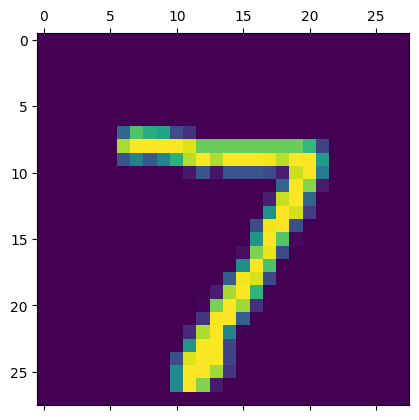

In [169]:
plt.matshow(X_test[0])

In [170]:
y_predicted = model.predict(X_test_flattened)
y_predicted[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([1.08789732e-06, 2.48464308e-13, 5.33650848e-07, 3.50360380e-04,
       8.81386786e-09, 1.66376310e-06, 2.72164387e-12, 9.99525547e-01,
       2.75052935e-06, 1.18126314e-04], dtype=float32)

In [171]:
np.argmax(y_predicted[0])

np.int64(7)

In [172]:
y_predicted_labels=[np.argmax(i) for i in y_predicted]

In [173]:
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 956,    0,    0,    1,    0,    3,   17,    1,    1,    1],
       [   0, 1104,    4,    2,    1,    1,    5,    2,   16,    0],
       [  18,    5,  883,   16,    9,    4,   28,   16,   47,    6],
       [   6,    1,   17,  906,    0,   25,    8,   15,   26,    6],
       [   3,    3,    1,    2,  889,    0,   20,    4,    6,   54],
       [  20,    2,    1,   25,    6,  768,   24,   11,   29,    6],
       [   8,    2,    2,    1,    4,    7,  934,    0,    0,    0],
       [   4,    4,   14,    4,    7,    0,    0,  937,    4,   54],
       [  17,    7,    4,   18,   10,   31,   24,   14,  839,   10],
       [  12,    8,    1,    6,   22,    7,    1,   12,    7,  933]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Test')

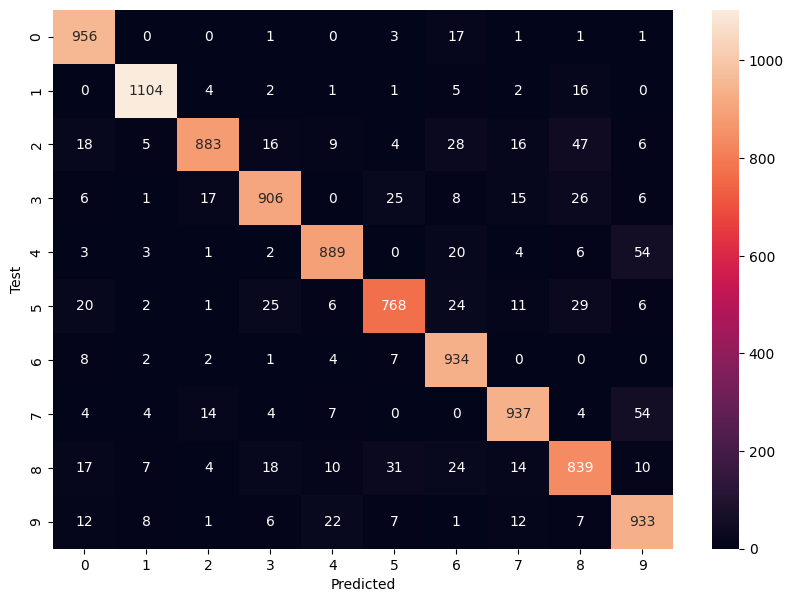

In [174]:
import seaborn as sn
plt.figure(figsize=(10, 7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Test")

In [176]:
model = keras.Sequential([
    Dense(728),
    Dense(100, activation="relu"),
    Dense(10, activation="sigmoid")
])
model.compile(
    optimizer = 'adam',
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.fit(X_train_flattened, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9316 - loss: 0.2293
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9589 - loss: 0.1335
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9627 - loss: 0.1146
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9617 - loss: 0.0991
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9607 - loss: 0.0907


In [177]:
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9500 - loss: 0.1669


[0.16687703132629395, 0.949999988079071]